In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
from dataclasses import dataclass, field, asdict
from enum import Enum
from typing import Callable
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
import os
import random
import json
from pathlib import Path

In [2]:
# To ensure reproductiblity
def set_seed(seed: int):
    random.seed(seed)

    np.random.seed(seed)

    tf.random.set_seed(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["TF_DETERMINISTIC_OPS"] = "1"

    physical_devices = tf.config.experimental.list_physical_devices("GPU")
    if physical_devices:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        tf.config.threading.set_intra_op_parallelism_threads(1)
        tf.config.threading.set_inter_op_parallelism_threads(1)

set_seed(1234)

En première partie on définit quelques fonctions utilitaires permettant une gestion plus fluide du chargement des bases d'images utilisées.
On normalise les images dans [0, 1] en pré-traitement.

In [3]:
# Use an enum for datasets  to avoid mistyping
class Dsets(str, Enum):
    mnist = "mnist"
    fmnist = "fashion_mnist"


# Use an enum for D1,D2 pair to avoid mistyping
class Dset_pairs(tuple[Dsets, Dsets], Enum):
    mnist_fmnist = (Dsets.mnist, Dsets.fmnist)


# Just a regular dataclass to handle the config logic
@dataclass
class Config:
    buffer_size: int = 10000
    batch_size: int = 64
    epochs: int = 5
    loss: str = "sparse_categorical_crossentropy"
    optimizer: str = "adam"
    metrics: list[str] = field(default_factory=lambda: ["accuracy"])

    dset_pair: Dset_pairs = Dset_pairs.mnist_fmnist
    input_shape: tuple[int, int, int] = field(default_factory=lambda: (28, 28, 1))


# Define loading/preprocess functions for each available datasets
def load_mnist(
    config: Config,
) -> tuple[tf.data.Dataset, tf.data.Dataset, int, dict[int, str]]:
    (mnist_train, mnist_test), mnist_info = tfds.load(
        "mnist", split=["train", "test"], as_supervised=True, with_info=True
    )

    # To allow for [0, 1] normalization
    def preprocess(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    mnist_train = (
        mnist_train.map(preprocess).batch(config.batch_size).prefetch(tf.data.AUTOTUNE)
    )
    mnist_test = (
        mnist_test.map(preprocess).batch(config.batch_size).prefetch(tf.data.AUTOTUNE)
    )

    class_names = {
        i: mnist_info.features["label"].int2str(i)
        for i in range(mnist_info.features["label"].num_classes)
    }
    return (
        mnist_train,
        mnist_test,
        mnist_info.features["label"].num_classes,
        class_names,
    )


def load_fmnist(
    config: Config,
) -> tuple[tf.data.Dataset, tf.data.Dataset, int, dict[int, str]]:
    (fmnist_train, fmnist_test), fmnist_info = tfds.load(
        "fashion_mnist", split=["train", "test"], as_supervised=True, with_info=True
    )

    # To allow for [0, 1] normalization
    def preprocess(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    fmnist_train = (
        fmnist_train.map(preprocess).batch(config.batch_size).prefetch(tf.data.AUTOTUNE)
    )
    fmnist_test = (
        fmnist_test.map(preprocess).batch(config.batch_size).prefetch(tf.data.AUTOTUNE)
    )
    class_names = {
        i: fmnist_info.features["label"].int2str(i)
        for i in range(fmnist_info.features["label"].num_classes)
    }
    return (
        fmnist_train,
        fmnist_test,
        fmnist_info.features["label"].num_classes,
        class_names,
    )


LOAD_MAPPER: dict[
    Dsets : Callable[
        Config, tuple[tf.data.Dataset, tf.data.Dataset, int, dict[int, str]]
    ]
] = {
    Dsets.mnist: load_mnist,
    Dsets.fmnist: load_fmnist,
}


# Function to merge labels from a dataset pairs by shifting their index
def merge_datasets(
    config: Config,
) -> tuple[
    tf.data.Dataset, tf.data.Dataset, tf.data.Dataset, tf.data.Dataset, dict[int, str]
]:
    global LOAD_MAPPER

    D1_train, D1_test, D1_classes, D1_names = LOAD_MAPPER[config.dset_pair[0]](config)
    D2_train, D2_test, _, D2_names = LOAD_MAPPER[config.dset_pair[1]](config)

    offset_D1_label = lambda img, lbl: (img, lbl)
    offset_D2_label = lambda img, lbl: (
        img,
        lbl + D1_classes,
    )  # Shift labels

    D1_train = D1_train.map(offset_D1_label)
    D2_train = D2_train.map(offset_D2_label)

    D1_test = D1_test.map(offset_D1_label)
    D2_test = D2_test.map(offset_D2_label)

    merged_class_names = {
        **D1_names,
        **{i + D1_classes: name for i, name in D2_names.items()},
    }

    return (
        D1_train,
        D2_train,
        D1_test,
        D2_test,
        merged_class_names,
    )

On effectue quelques essais pour voir si les fonctions donnent des retours cohérents.

In [4]:
config = Config()
d1_train, _, d2_train, _, merged_class_names = merge_datasets(config)

for images, labels in d1_train.take(1):
    print(images.shape, labels.shape)

Dl Completed...:   0%|          | 0/5 [00:00<?, ? file/s]

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

...

Generating train examples...:   0%|          | 0/60000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.GWPBBB_3.0.1/fashion_mnist-train.tfrecord*...:   …

Generating test examples...:   0%|          | 0/10000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.GWPBBB_3.0.1/fashion_mnist-test.tfrecord*...:   0…

Dataset fashion_mnist downloaded and prepared to /root/tensorflow_datasets/fashion_mnist/3.0.1. Subsequent calls will reuse this data.
(64, 28, 28, 1) (64,)


On donne quelques fonctions de visualisations rapides de la base dans la cellule suivante.

In [5]:
def visualize_images(
    dataset: tf.data.Dataset, class_names: dict[int, str], cmap="gray", title="D1 train"
) -> None:
    dataset_iter = iter(dataset.take(1))

    # Remember that images are loaded by batch
    images, labels = next(dataset_iter)
    images = images.numpy()
    labels = labels.numpy() if isinstance(labels, tf.Tensor) else labels

    fig, ax = plt.subplots(3, 3)
    for i in range(9):
        row, col = i // 3, i % 3
        ax[row, col].imshow(images[i], cmap=cmap)
        ax[row, col].set_title(class_names[labels[i]])

        ax[row, col].axis("off")

    fig.tight_layout()
    fig.suptitle(title, fontsize=16)
    fig.subplots_adjust(top=0.85)
    plt.show()


def plot_class_distribution(
    dataset: tf.data.Dataset, num_classes: int, title: str = "D1 train"
) -> None:
    class_counts = np.zeros(num_classes, dtype=int)
    total = 0

    for _, labels in dataset:
        labels = labels.numpy().flatten()
        for label in labels:
            class_counts[label] += 1
            total += 1

    plt.figure(figsize=(8, 5))
    plt.bar(
        range(num_classes),
        class_counts,
        tick_label=[str(i) for i in range(num_classes)],
        color="skyblue",
    )
    plt.xlabel("Class Index")
    plt.ylabel("Frequency")
    plt.title(f"Class Distribution in Dataset {title}", fontsize=16)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()


Quelques essais de visualisations, comme on s'y attend les bases fusionnées ont bien 0 instances des classes de l'autre.

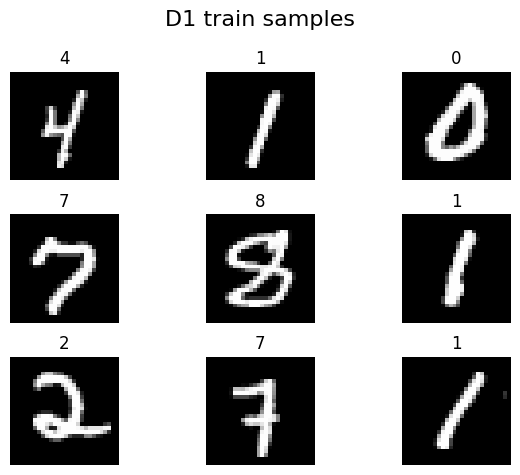

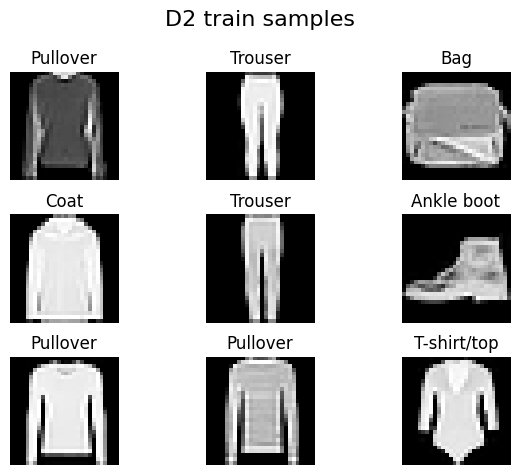

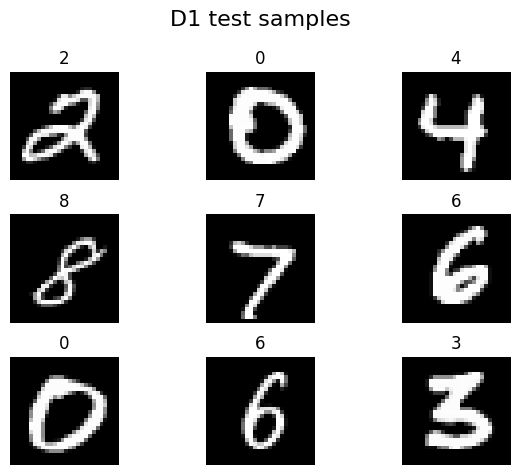

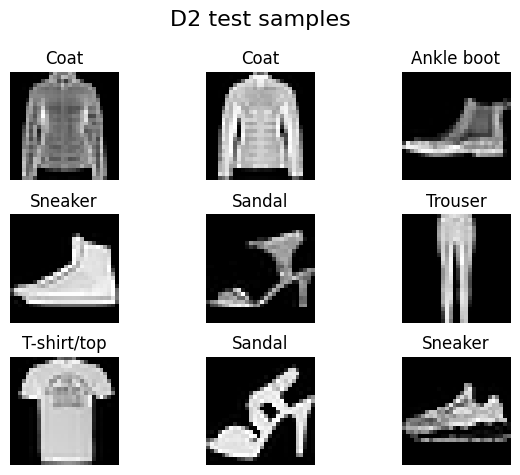

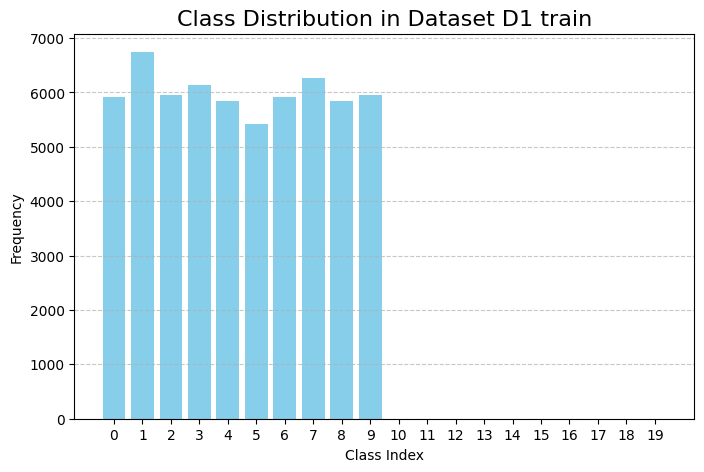

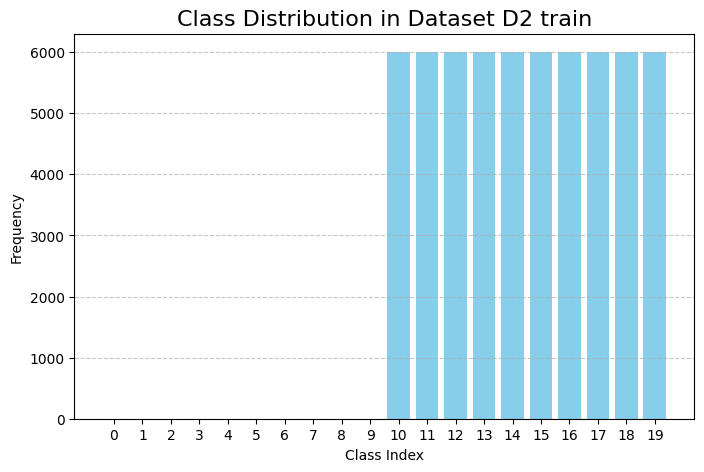

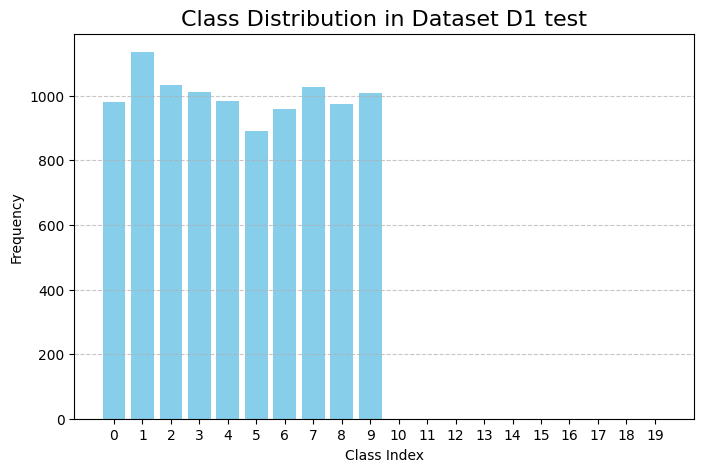

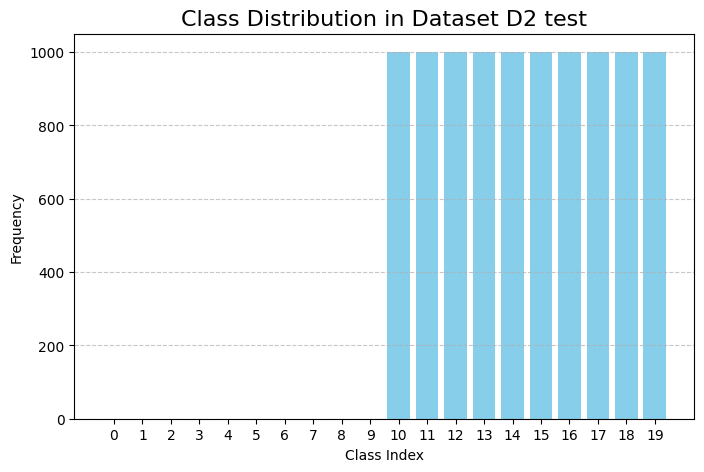

In [6]:
config = Config()
d1_train, d2_train, d1_test, d2_test, class_names = merge_datasets(config)

visualize_images(d1_train, class_names, title="D1 train samples")
visualize_images(d2_train, class_names, title="D2 train samples")

visualize_images(d1_test, class_names, title="D1 test samples")
visualize_images(d2_test, class_names, title="D2 test samples")

plot_class_distribution(d1_train, num_classes=len(class_names), title="D1 train")
plot_class_distribution(d2_train, num_classes=len(class_names), title="D2 train")

plot_class_distribution(d1_test, num_classes=len(class_names), title="D1 test")
plot_class_distribution(d2_test, num_classes=len(class_names), title="D2 test")


On remarque que la base F-MNIST est strictement homogène en terme de nombre d'instance par classe contrairement à MNIST qui elle ne l'est pas exactement.

Dans la suite on définit la logique d'entrainement et le réseau de convolution employé.
En particulier on emploi un CNN basique avec 3 couches de convolutions 3x3, avec ReLU comme fonction d'activation, des MaxPoolin2D successifs et 2 couches denses de décisions comportant respectivement 128 neuronnes (avec ReLU comme fonction d'activation) et nombre de classes avec une fonction softmax pour donner une probabilité d'appartenance à une classe.
Pour l'entrainement on prend les paramètres par défaut donnés dans la classe Config, c'est-à-dire 5 epochs, la fonction coût utilisée est l'entropie croisée (en particulier la sparse_categorical_crossentropy car les annotations sont sous format entier).
On suit la précision comme métrique de performance du modèle, et l'optimiseur Adam est employé avec les paramètres par défaut de TF.

In [7]:
class CNNModel:
    def __init__(
        self,
        input_shape: tuple[int, int, int],
        num_classes: int,
    ) -> None:
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model: tf.keras.Model | None = None
        self.history: tf.keras.callbacks.History = None

    def build_model(self, config: Config) -> None:
        self.model = models.Sequential(
            [
                layers.InputLayer(input_shape=self.input_shape),
                layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
                layers.MaxPooling2D((2, 2)),
                layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
                layers.MaxPooling2D((2, 2)),
                layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
                layers.MaxPooling2D((2, 2)),
                layers.Flatten(),
                layers.Dense(128, activation="relu"),
                layers.Dense(self.num_classes, activation="softmax"),
            ]
        )
        self.model.compile(
            optimizer=config.optimizer,
            loss=config.loss,
            metrics=config.metrics,
        )

    def save_weights(self, filepath: Path) -> None:
        if self.model:
            self.model.save_weights(filepath)
        else:
            raise ValueError("Model is not built. Call 'build_model()' first.")

    def load_weights(self, filepath: Path) -> None:
        if self.model:
            self.model.load_weights(filepath)
        else:
            raise ValueError("Model is not built. Call 'build_model()' first.")

    def plot_training_curves(self, save_path: Path | None = None) -> None:
        if self.history is None:
            raise ValueError("Please train the model before!")

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(self.history.history["accuracy"], label="Train Accuracy")
        plt.plot(self.history.history["val_accuracy"], label="Val Accuracy")
        plt.title("Accuracy")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(self.history.history["loss"], label="Train Loss")
        plt.plot(self.history.history["val_loss"], label="Val Loss")
        plt.title("Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()

        if save_path is not None:
            plt.savefig(save_path)

        plt.show()

    def train(
        self, train_dset: tf.data.Dataset, val_dset: tf.data.Dataset, epochs: int
    ) -> None:
        if self.model:
            self.history = self.model.fit(
                train_dset, epochs=epochs, validation_data=val_dset
            )
        else:
            raise ValueError("Model is not built. Call 'build_model()' first.")

    def test_model(self, test_data: tf.data.Dataset) -> tuple[float, float]:
        if self.model:
            test_loss, test_accuracy = self.model.evaluate(test_data)
            print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
            return test_loss, test_accuracy
        else:
            raise ValueError("Model is not built. Call 'build_model()' first.")

On réalise un petit essai d'entrainement sans sauvegarder quoi que ce soit pour s'assurer que le code fonctionne correctement.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8597 - loss: 0.4450 - val_accuracy: 0.9820 - val_loss: 0.0577
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9850 - loss: 0.0523 - val_accuracy: 0.9871 - val_loss: 0.0400
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9890 - loss: 0.0372 - val_accuracy: 0.9889 - val_loss: 0.0368
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9915 - loss: 0.0290 - val_accuracy: 0.9888 - val_loss: 0.0376
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9934 - loss: 0.0211 - val_accuracy: 0.9871 - val_loss: 0.0478


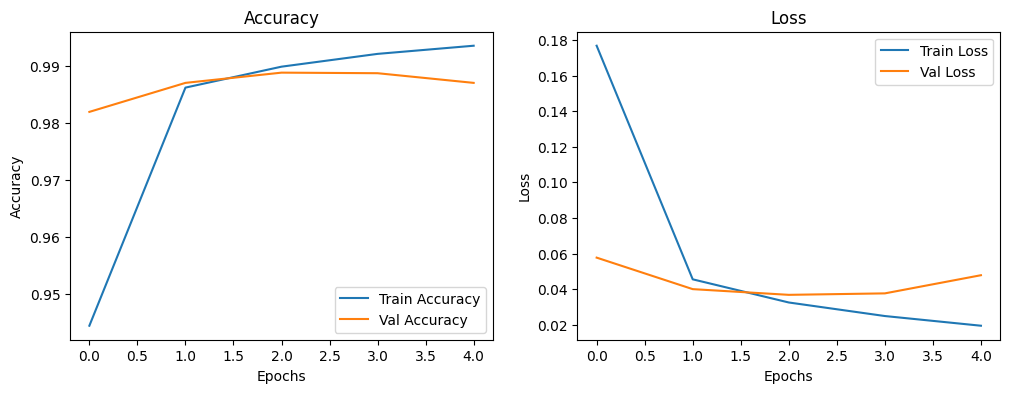

In [8]:
config = Config()
d1_train, d2_train, d1_test, d2_test, class_names = merge_datasets(config)

cnn = CNNModel(config.input_shape, num_classes=len(class_names))
cnn.build_model(config)

cnn.train(train_dset=d1_train, val_dset=d1_test, epochs=config.epochs)
cnn.plot_training_curves()

L'entrainement de classification sur MNIST semble donner de très bon résultats en seulement quelques epochs. On essaye d'effectuer le transfert d'entrainement dans la suite.

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.8571 - loss: 0.4457 - val_accuracy: 0.9839 - val_loss: 0.0485
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9854 - loss: 0.0501 - val_accuracy: 0.9872 - val_loss: 0.0390
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9899 - loss: 0.0355 - val_accuracy: 0.9888 - val_loss: 0.0334
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9926 - loss: 0.0256 - val_accuracy: 0.9901 - val_loss: 0.0366
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9946 - loss: 0.0189 - val_accuracy: 0.9889 - val_loss: 0.0363


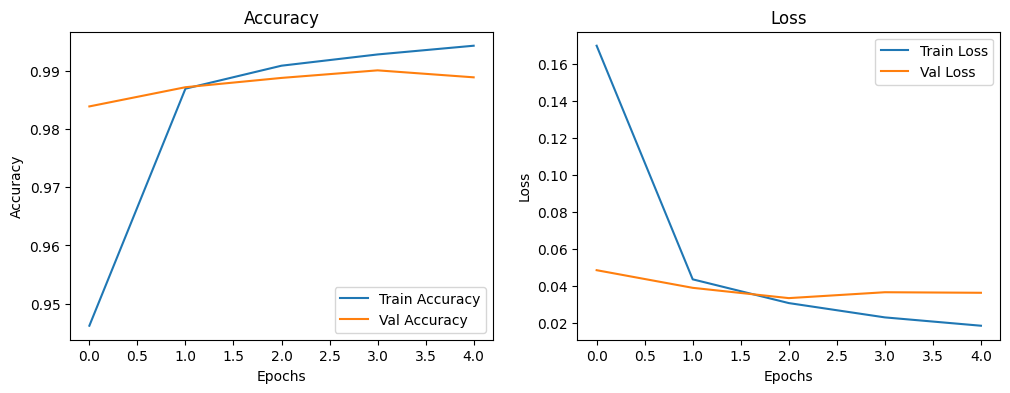

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9883 - loss: 0.0359
Test Loss: 0.0363, Test Accuracy: 0.9889
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0000e+00 - loss: 11.8014
Test Loss: 11.7741, Test Accuracy: 0.0000
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7262 - loss: 0.8853 - val_accuracy: 0.8777 - val_loss: 0.3382
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8884 - loss: 0.3096 - val_accuracy: 0.8924 - val_loss: 0.2923
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9048 - loss: 0.2638 - val_accuracy: 0.9009 - val_loss: 0.2774
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9142 - loss: 0.2368 - val_accuracy: 0.9040 - val_loss: 0.2716
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9220 - loss: 0.2159 - val_accuracy: 0.9067 - val_loss: 0.2653


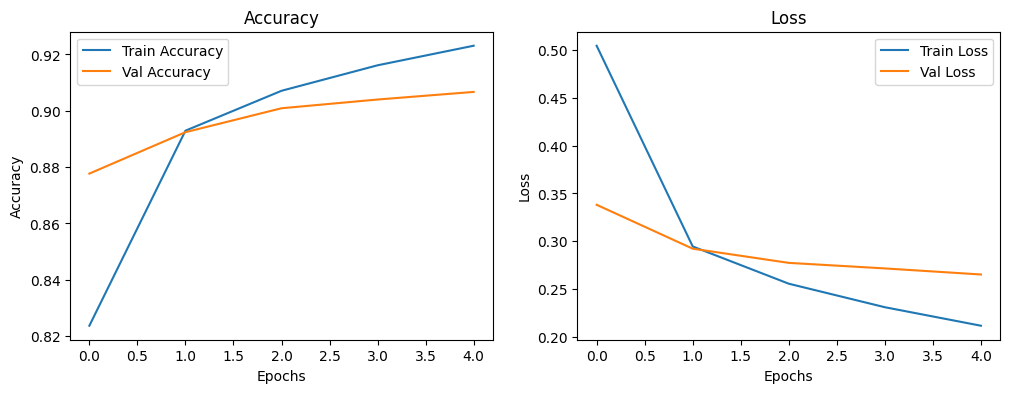

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: 27.1577
Test Loss: 27.0162, Test Accuracy: 0.0000
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9045 - loss: 0.2606
Test Loss: 0.2653, Test Accuracy: 0.9067


In [9]:
# There's 2 trainings, the first one in 100/0 proportion, loss and accuracy
# are with respect to the validation set
@dataclass
class Results:
    save_dir: Path
    config: Config

    training_1_d1_accuracy: float | None = None
    training_1_d1_loss: float | None = None
    training_1_d2_accuracy: float | None = None
    training_1_d2_loss: float | None = None

    training_2_d1_accuracy: float | None = None
    training_2_d1_loss: float | None = None
    training_2_d2_accuracy: float | None = None
    training_2_d2_loss: float | None = None

    # As I am using Config that has a tuple of an enum in its field turning it
    # into a dict causes issue so I just convert it to a regular tuple of str before saving it
    def save(self) -> None:
        save_output = results.save_dir / "results.json"
        self.config.dset_pair = tuple(item.value for item in self.config.dset_pair)  # type: ignore
        self.save_dir = self.save_dir.as_posix()  # type: ignore
        with open(save_output, "w") as file:
            json.dump(asdict(results), file, indent=1)


# Load config, dsets and and the model
config = Config()
d1_train, d2_train, d1_test, d2_test, merged_class_names = merge_datasets(config)

results = Results(config=config, save_dir=Path("data/mnist-fmnist"))
os.makedirs(results.save_dir, exist_ok=True)

cnn = CNNModel(
    config.input_shape,
    len(merged_class_names),
)
cnn.build_model(config)

# Train the model on the D1 (with D1 val)
cnn.train(train_dset=d1_train, val_dset=d1_test, epochs=config.epochs)

# Save the model, nomenclature for weights D1-D2-proportion in the dset
cnn.save_weights(results.save_dir / "mnist-fmnist-100-0.weights.h5")
cnn.plot_training_curves(save_path=results.save_dir / "training_1_curves.png")

# Test model on D1-test and D2-test, obviously catastrophic performance on D2
d1_test_loss, d1_test_accuracy = cnn.test_model(test_data=d1_test)
d2_test_loss, d2_test_accuracy = cnn.test_model(test_data=d2_test)

results.training_1_d1_accuracy = d1_test_accuracy
results.training_1_d1_loss = d1_test_loss
results.training_1_d2_accuracy = d2_test_accuracy
results.training_1_d2_loss = d2_test_loss

# Retrain it on D2 this time (with D2-val)
cnn.train(train_dset=d2_train, val_dset=d2_test, epochs=config.epochs)

# Save the model, nomenclature for weights D1-D2-D1-proportion in the dset
cnn.save_weights(results.save_dir / "mnist-fmnist-0-100.weights.h5")
cnn.plot_training_curves(save_path=results.save_dir / "training_2_curves.png")

# Test model on D1-test and D2-test
d1_test_loss, d1_test_accuracy = cnn.test_model(test_data=d1_test)
d2_test_loss, d2_test_accuracy = cnn.test_model(test_data=d2_test)

results.training_2_d1_accuracy = d1_test_accuracy
results.training_2_d1_loss = d1_test_loss
results.training_2_d2_accuracy = d2_test_accuracy
results.training_2_d2_loss = d2_test_loss

# Saving results
results.save()
